In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_table("data/Hs_SS_PCs_FWT_LWT_Precip_Cantabria_reg_guided.txt")

In [3]:
cols = ["yyyy", "mm", "dd", "Hs"] + [col for col in data.columns if col.startswith("PC") and not col.endswith("_SS")] + ["FWT"]
df_hs = data[cols]

In [4]:
days_in_month = {
    1: 31,
    2: 28.25,
    3: 31,
    4: 30,
    5: 31,
    6: 30,
    7: 31,
    8: 31,
    9: 30,
    10: 31,
    11: 30,
    12: 31
}

df_hs.loc[:,["time"]] = (
    df_hs["yyyy"] - np.min(df_hs["yyyy"])
    + (df_hs["mm"] - 1) / 12
    + (df_hs["dd"] - 1) / df_hs["mm"].map(days_in_month) / 12 
)

In [5]:
df_hs["time"]

0         0.000000
1         0.002688
2         0.005376
3         0.008065
4         0.010753
           ...    
14605    39.986559
14606    39.989247
14607    39.991935
14608    39.994624
14609    39.997312
Name: time, Length: 14610, dtype: float64

In [6]:
df_hs_monthly_idx = df_hs.groupby(["yyyy", "mm"])["Hs"].idxmax()

In [7]:
df_hs_monthly = df_hs.loc[df_hs_monthly_idx].reset_index(drop=True)

In [8]:
Hsdata = df_hs_monthly.drop(columns=["yyyy", "mm", "dd"])

In [9]:
hsmax = Hsdata.to_numpy()[:,0]
time = Hsdata.to_numpy()[:,-1]
covariates = {col: Hsdata[col] for col in Hsdata.columns[1:-1]}

In [10]:
covariates_df = pd.DataFrame(covariates)
scaler = StandardScaler()
scaled_covariates_df = pd.DataFrame(
    scaler.fit_transform(covariates_df), 
    columns=covariates_df.columns
)

## General fit

In [11]:
from bluemath_tk.distributions.nonstat_gev import NonStatGEV

In [12]:
nonstationary_gev = NonStatGEV(
    xt=hsmax,
    t=time,
    covariates=scaled_covariates_df.iloc[:,:10],
    harms=False,
    trends=False,
    var_name="Hs",
)

In [13]:
fit_result = nonstationary_gev.fit(
    nmu=0,
    npsi=0,
    ngamma=0,
    ntrend_loc=0,
    list_loc="all", 
    ntrend_sc=0, 
    list_sc="all", 
    ntrend_sh=0, 
    list_sh="all",
    options = {
        "gtol": 1e-4,
        "xtol": 1e-4,
        "barrier_tol": 1e-3,
        "maxiter": 1000,
        # "verbose": 3,
        # "initial_constr_penalty": 10.0,
        # "initial_barrier_parameter": 1e-2,
        "finite_diff_rel_step": 1e-6,
        # "workers":-1
    }
)

In [14]:
nonstationary_gev.summary()


Fitted Time-Dependent GEV model for Hs

Location Parameters
----------------------------------------------------------------------
Parameter           Estimate      Std. Error           95% CI         
----------------------------------------------------------------------
Beta0                 3.9957          0.0486       [  3.9005,  4.0909]
Beta_cov1             0.7465          0.0492       [  0.6500,  0.8430]
Beta_cov2            -0.3619          0.0523       [ -0.4643, -0.2595]
Beta_cov3            -0.0216          0.0454       [ -0.1106,  0.0674]
Beta_cov4             0.4583          0.0444       [  0.3712,  0.5454]
Beta_cov5             0.5870          0.0445       [  0.4997,  0.6742]
Beta_cov6             0.1741          0.0485       [  0.0790,  0.2691]
Beta_cov7            -0.0036          0.0506       [ -0.1028,  0.0955]
Beta_cov8             0.1502          0.0376       [  0.0765,  0.2238]
Beta_cov9            -0.3052          0.0465       [ -0.3964, -0.2140]
Beta_cov10      

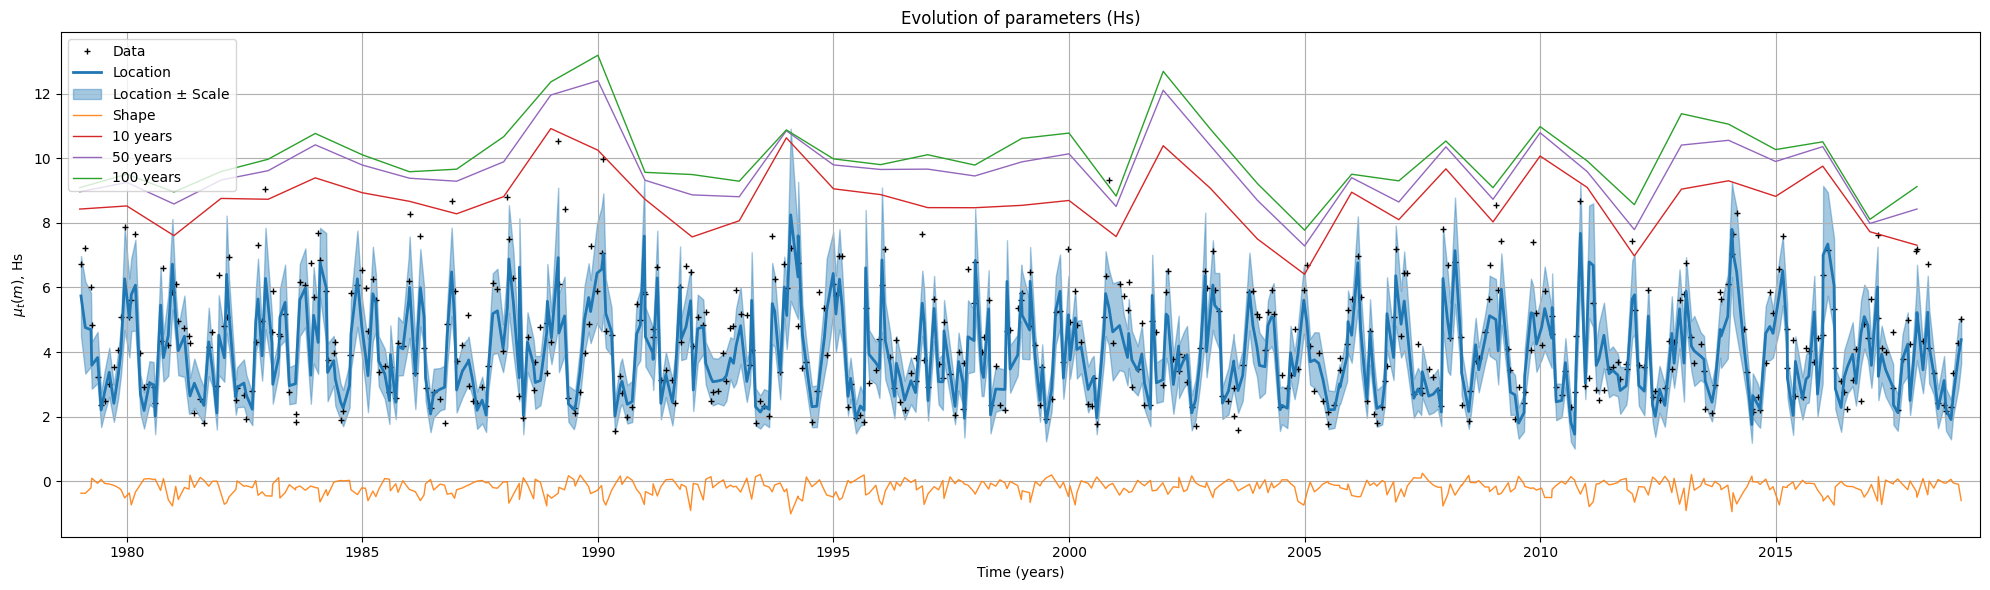

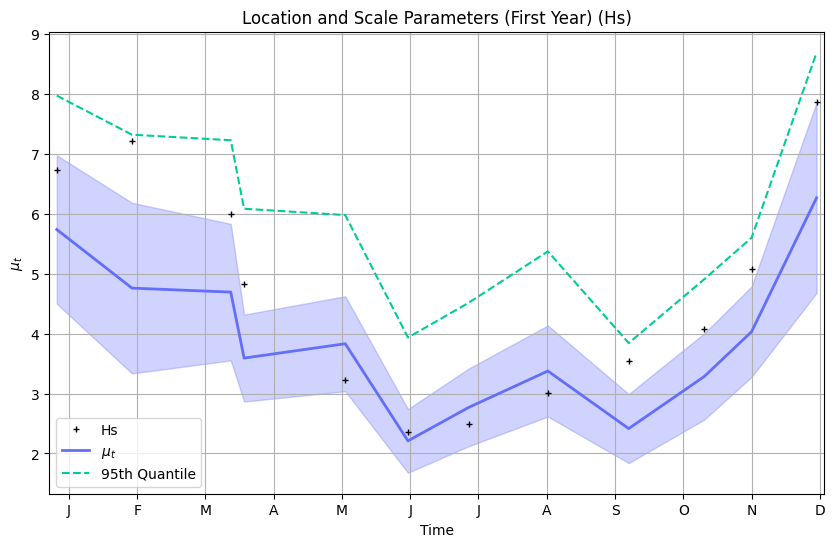

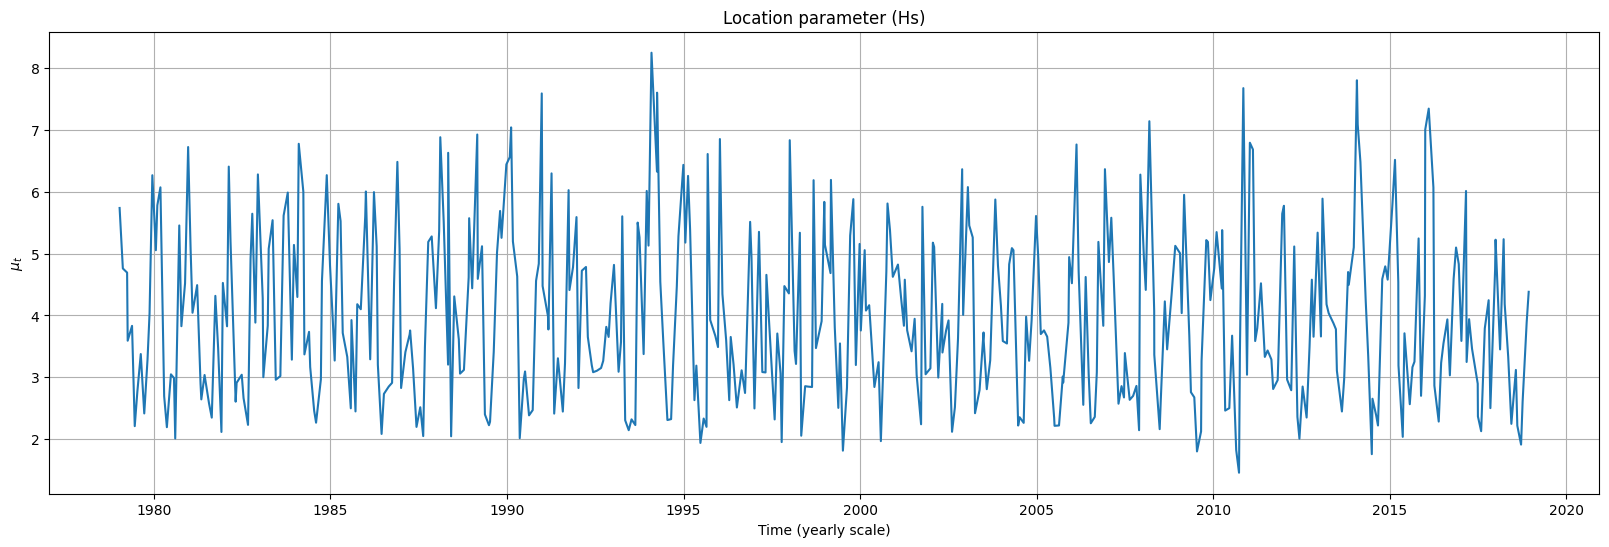

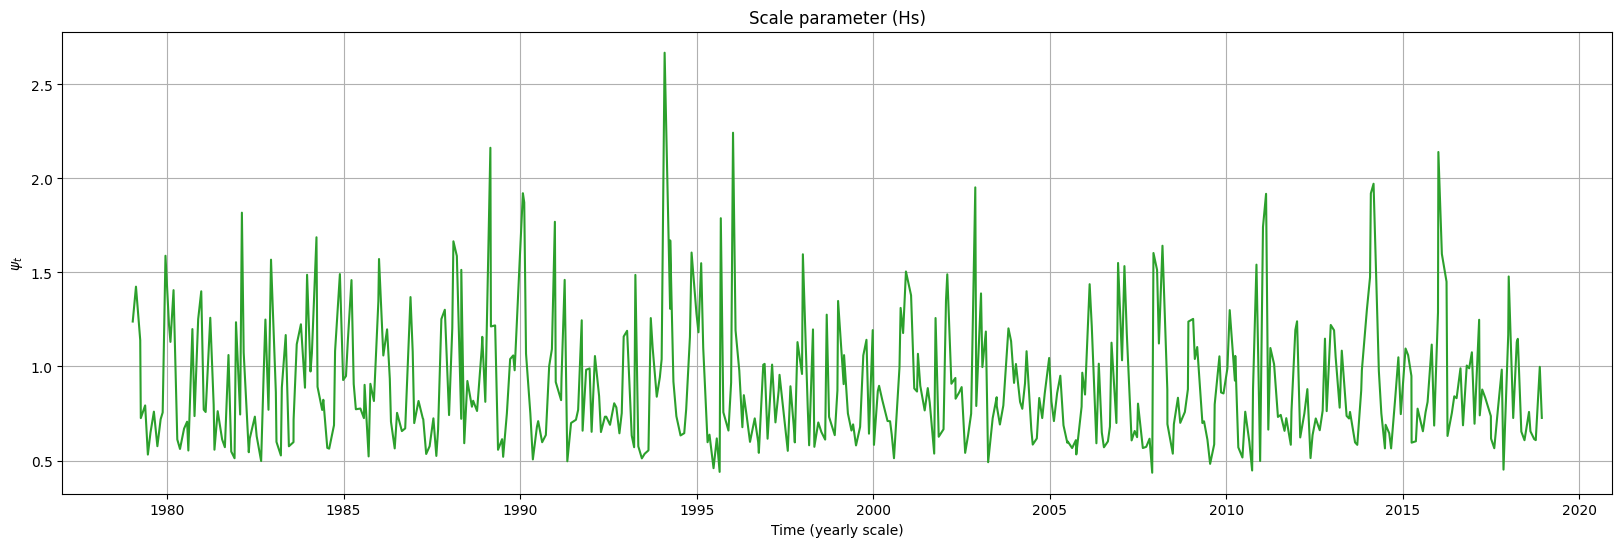

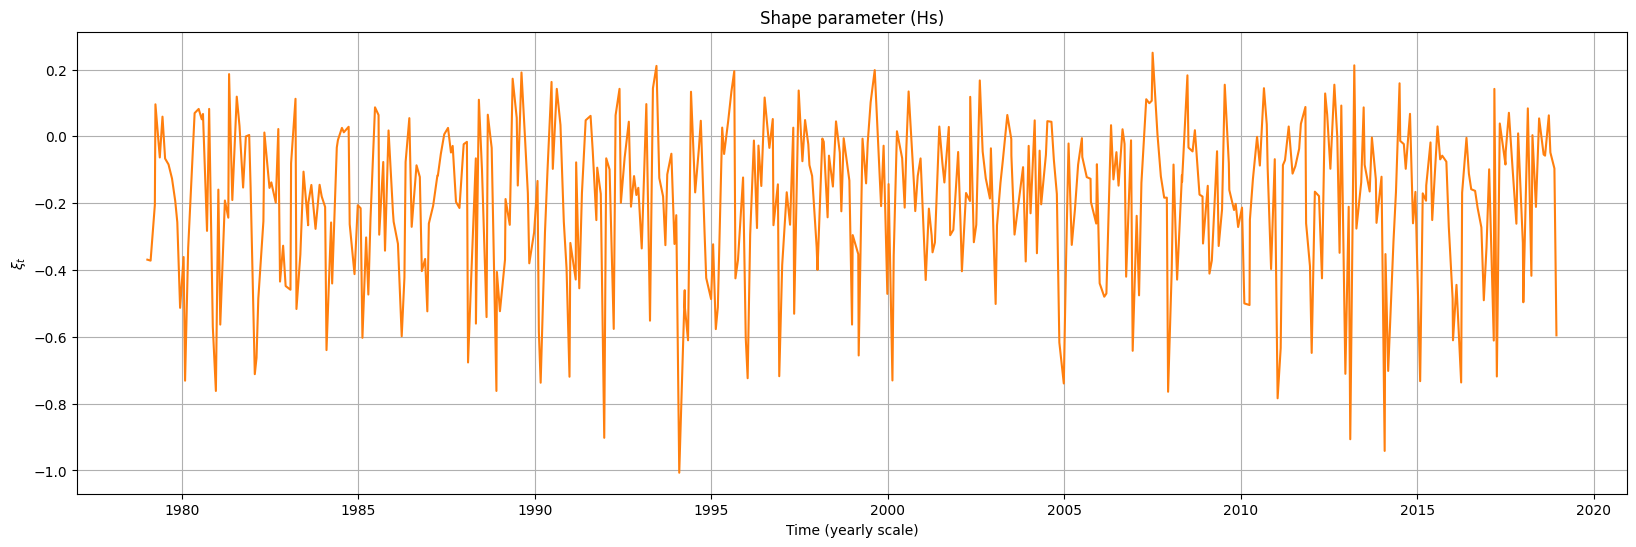

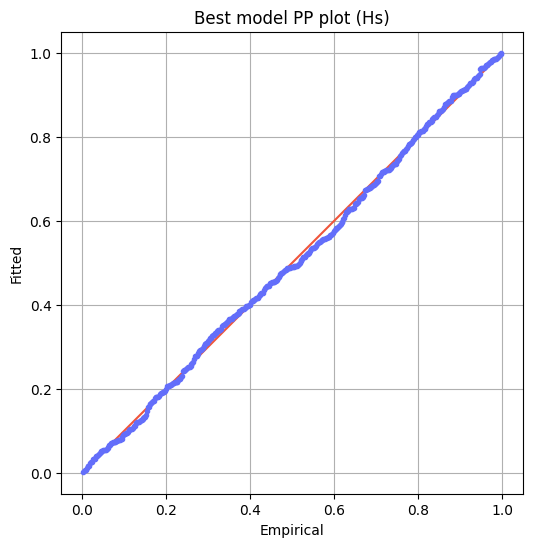

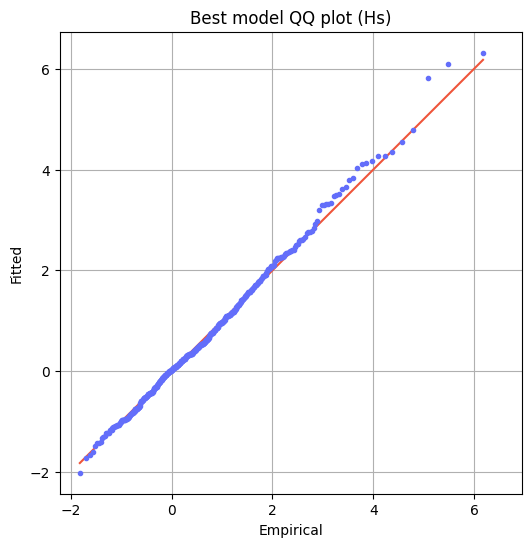

In [15]:
nonstationary_gev.plot(return_plot=False, init_year=df_hs["yyyy"].min())

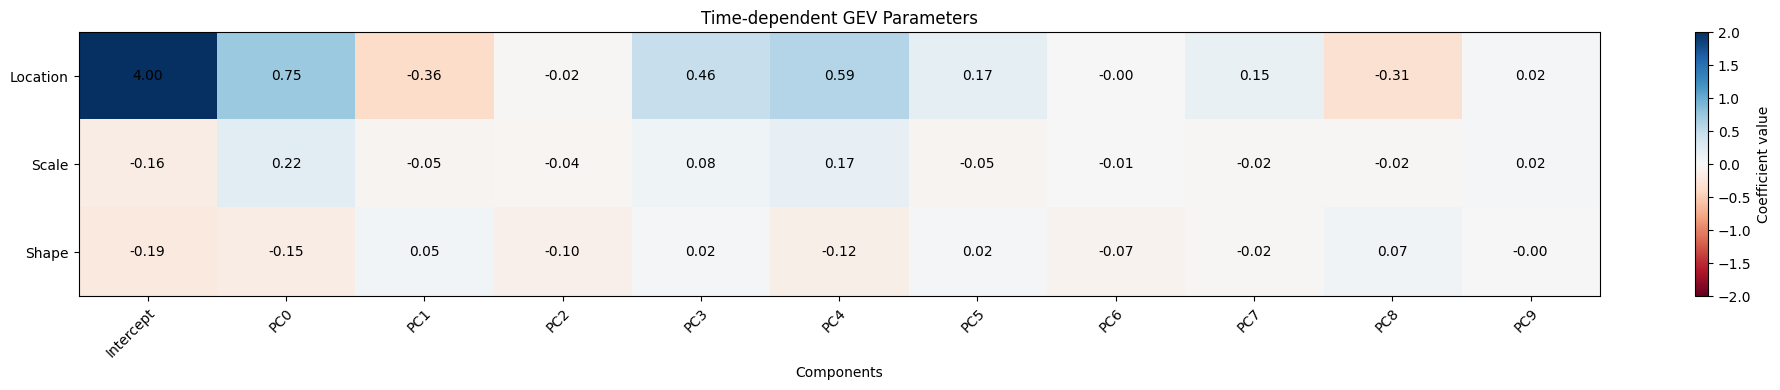

In [16]:
nonstationary_gev.paramplot()

In [17]:
nonstationary_gev.save_model("nonstationary_gev_cov.pkl")

## PRUEBA RAPIDA

In [18]:
from bluemath_tk.core.io import load_model
nonstationary_gev = load_model("nonstationary_gev_cov.pkl")

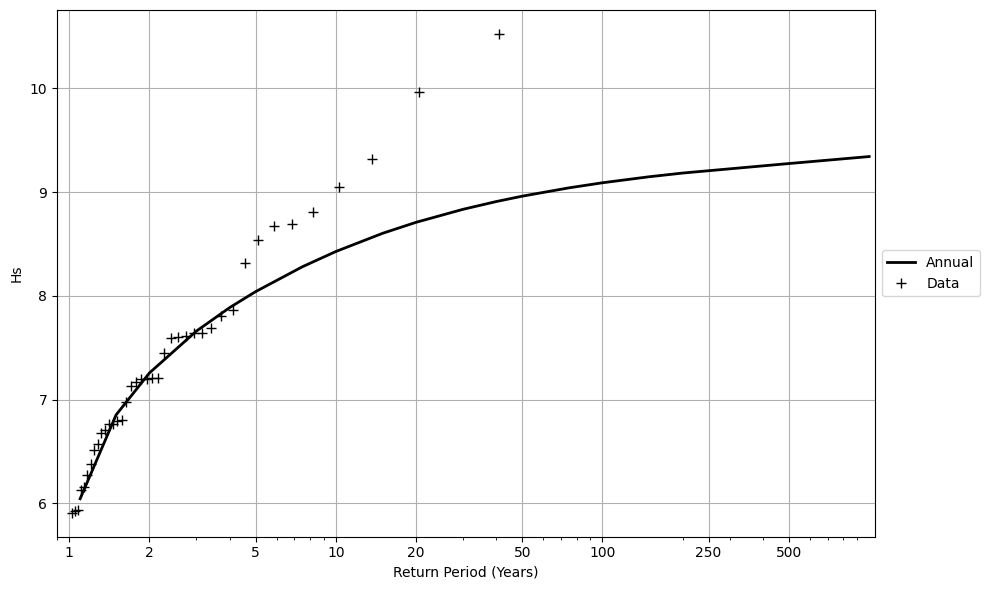

In [19]:
nonstationary_gev.returnperiod_plot(monthly_plot=False, conf_int=False)

## Harmonic fit

In [20]:
nonstationary_gev2 = NonStatGEV(
    xt=hsmax,
    t=time,
    covariates=None,
    harms=True,
    trends=False,
    var_name="Hs",
)

In [21]:
fit_result = nonstationary_gev2.auto_adjust()

Starting Harmonic iterative process
Iteration:  0 - AIC:  1842.8949788335
Iteration:  1 - AIC:  1531.6914074217711
Iteration:  2 - AIC:  1464.4874849688683
Iteration:  3 - AIC:  1454.4326606002123
Iteration:  4 - AIC:  1448.22279791894
Iteration:  5 - AIC:  1450.0017554897745
End of the Harmonic iterative process
Harmonic AIC: 1448.22279791894 

No covariates provided, skipping Covariates iterative process 



In [22]:
nonstationary_gev2.summary()


Fitted Time-Dependent GEV model for Hs

Location Parameters
----------------------------------------------------------------------
Parameter           Estimate      Std. Error           95% CI         
----------------------------------------------------------------------
Beta0                 3.8341          0.0533       [  3.7296,  3.9385]
Beta1 (sin)           1.5643          0.0658       [  1.4354,  1.6932]
Beta1 (cos)           0.3395          0.0695       [  0.2033,  0.4757]

Scale Parameters
----------------------------------------------------------------------
Parameter           Estimate      Std. Error           95% CI         
----------------------------------------------------------------------
Alpha0               -0.0530          0.0364       [ -0.1244,  0.0183]
Alpha1 (sin)          0.5153          0.0522       [  0.4130,  0.6176]
Alpha1 (cos)          0.0871          0.0521       [ -0.0151,  0.1893]
Alpha2 (sin)         -0.2098          0.0493       [ -0.3065, -0.1130

In [23]:
nonstationary_gev2.save_model("nonstationary_gev_harm.pkl")

In [24]:
from bluemath_tk.core.io import load_model
nonstationary_gev2 = load_model("nonstationary_gev_harm.pkl")

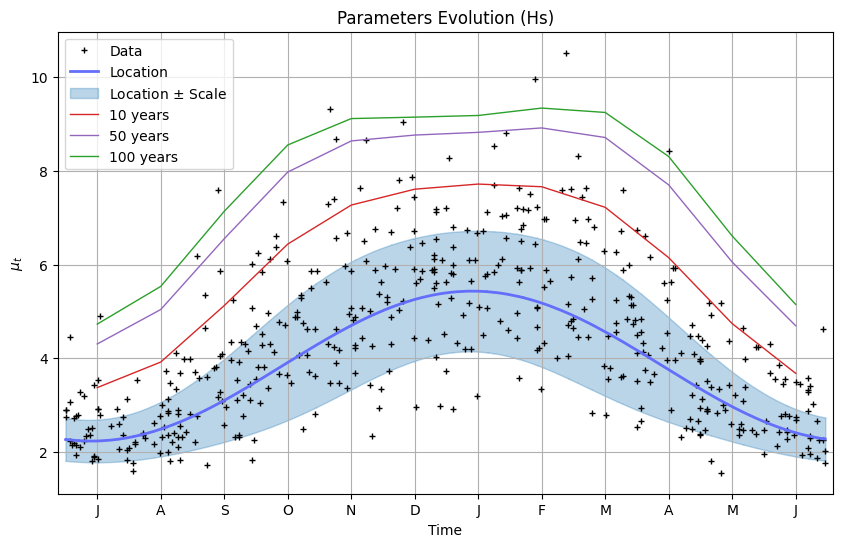

<Figure size 640x480 with 0 Axes>

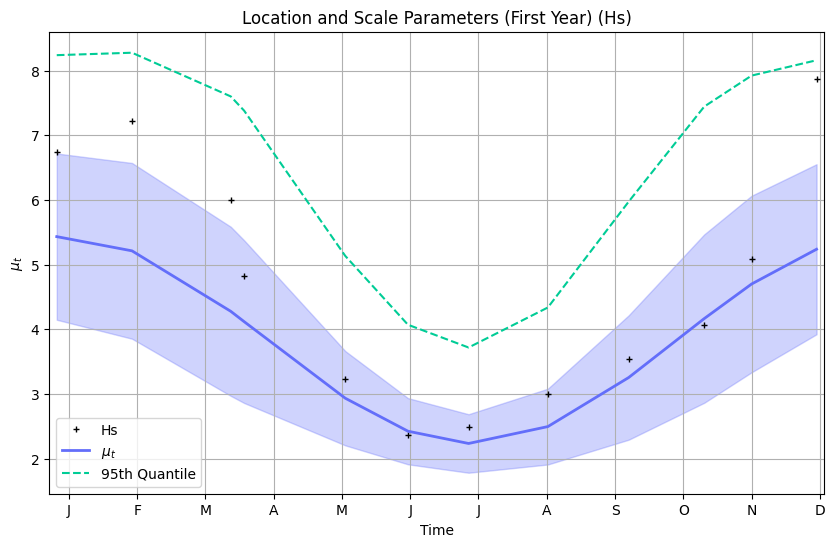

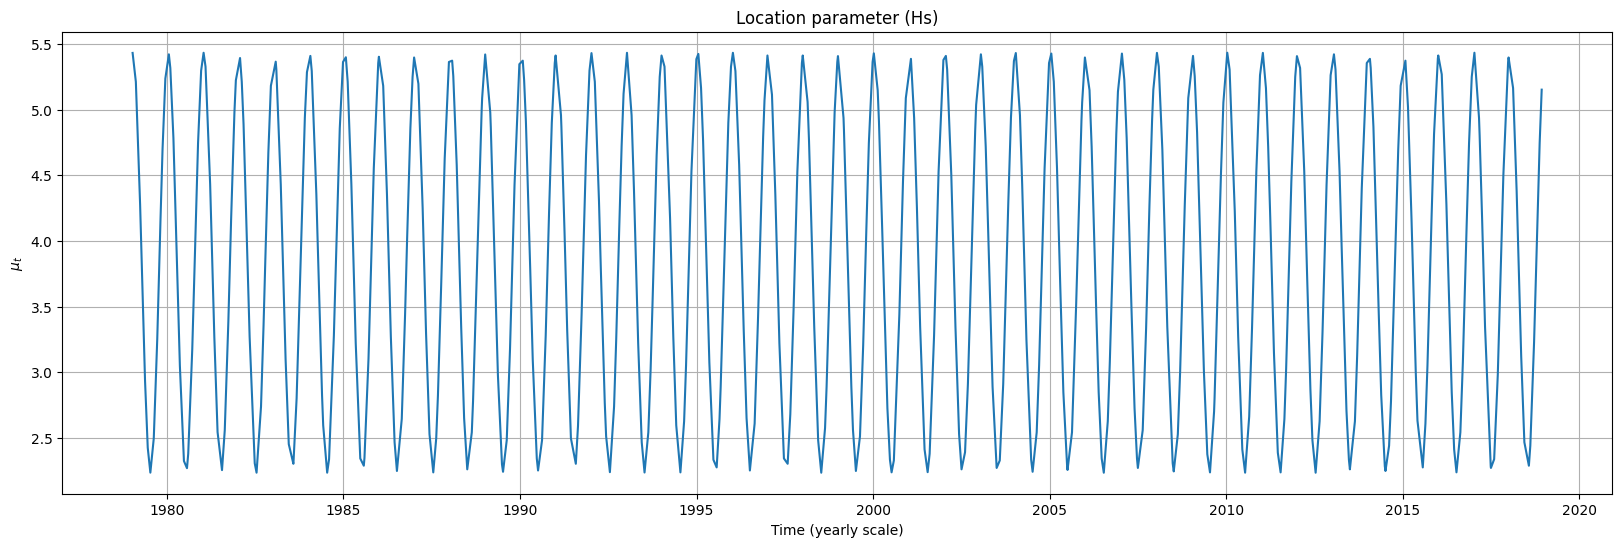

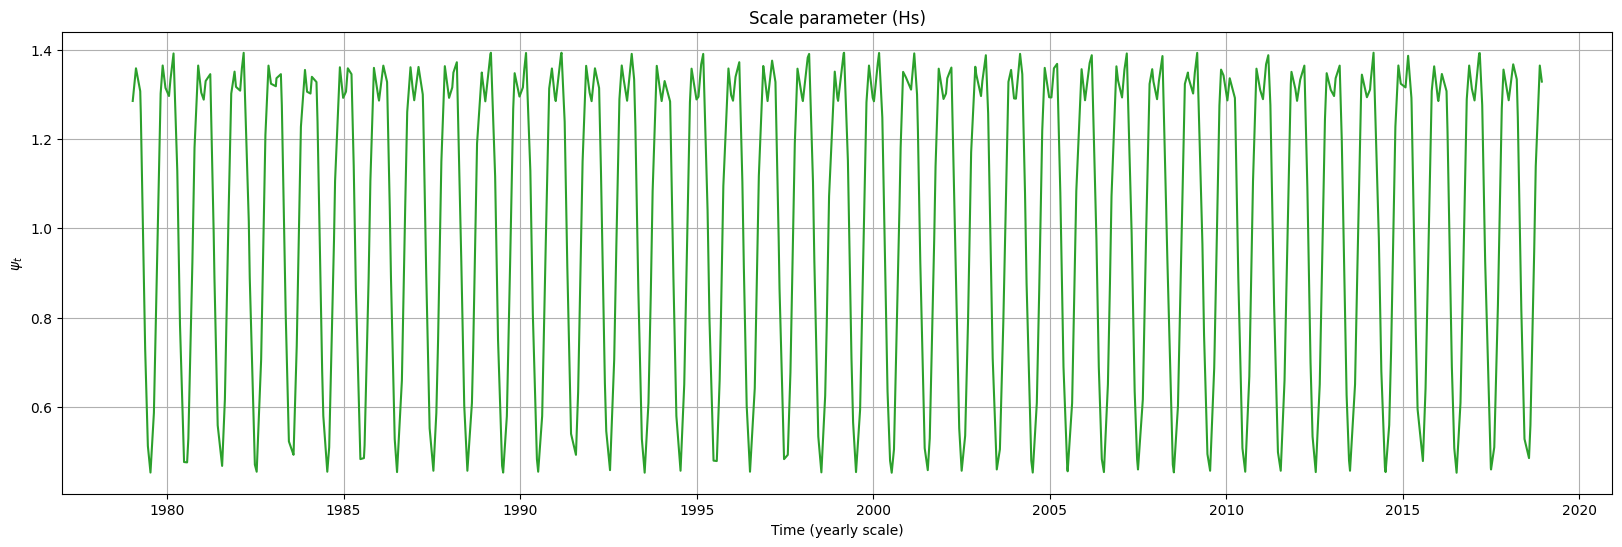

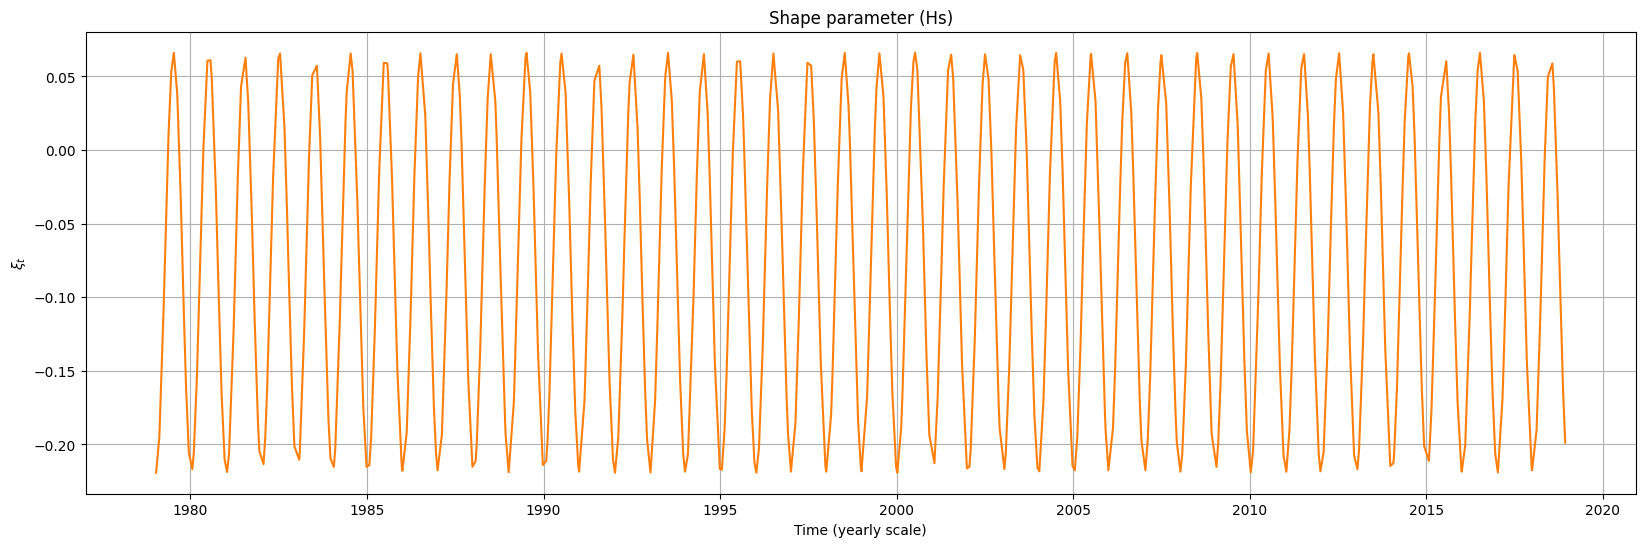

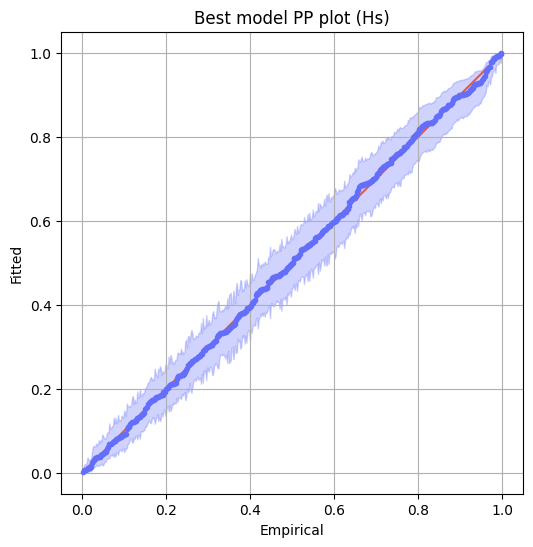

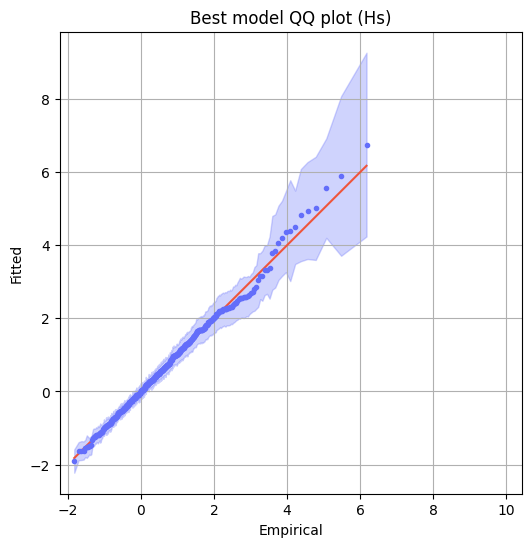

In [25]:
nonstationary_gev2.plot(return_plot=False, init_year=df_hs["yyyy"].min())

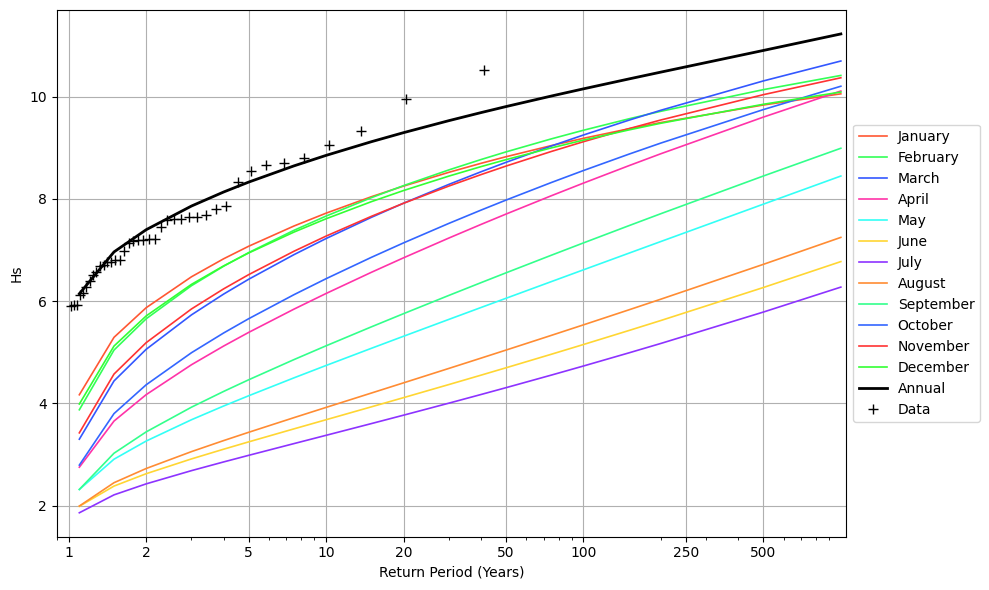

In [26]:
nonstationary_gev2.returnperiod_plot(monthly_plot=True, conf_int=False)